In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import import_ipynb
import sys
sys.path.insert(0, os.path.abspath('..'))
from ai_models.simca import SIMCAModel, SIMCAClassModel
from pathlib import Path
%matplotlib inline

In [2]:
# ---- SIMCA parameters ----
alpha = 0.01           # significance level (1 - confidence level)
n_components = 1       # number of PCA components per class
od_method = 'box'      # 'percentile', 'jackson', 'box'
sd_method = 'f'        # 'f', 'chi2', 'percentile'
rule = 'sim'           # 'sim', 'alt', 'ci', 'dd' — decision rule

../data/olive_oil/Replicate_011/Replicate_011_20251119: 10 FLUO files
../data/olive_oil/Replicate_012/Replicate_012_20251119: 10 FLUO files
../data/olive_oil/Replicate_021/Replicate_021_20251119: 10 FLUO files
../data/olive_oil/Replicate_022/Replicate_022_20251119: 10 FLUO files

Ukupan broj XVOO_NONE FLUO merenja: 40
xvoo_none_raw shape: (40, 288)


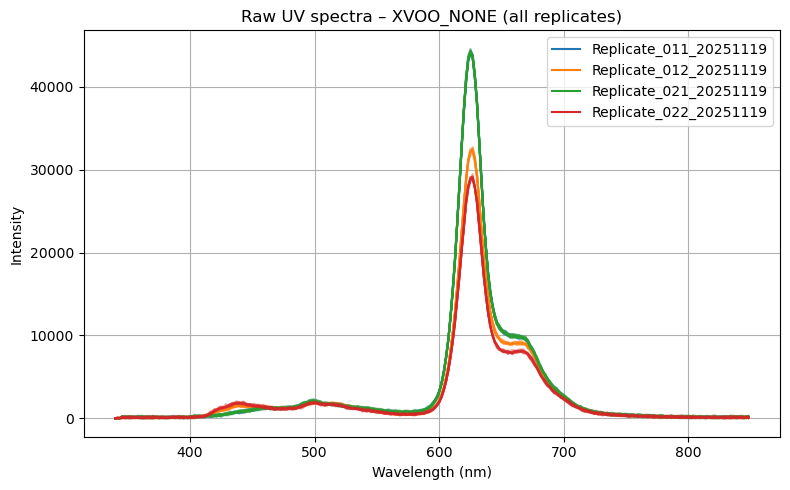

In [3]:
replicate_folders = [
    r"../data/olive_oil/Replicate_011/Replicate_011_20251119",
    r"../data/olive_oil/Replicate_012/Replicate_012_20251119",
    r"../data/olive_oil/Replicate_021/Replicate_021_20251119",
    r"../data/olive_oil/Replicate_022/Replicate_022_20251119",
    # r"../data/olive_oil/Replicate_011/Replicate_011_20251230",
]

xvoo_none_raw = []
wavelengths = None
file_counter = 0

for base_folder in replicate_folders:
    xvoo_none_fluo_path = os.path.join(base_folder, "xvoo_none", "FLUO")

    if not os.path.exists(xvoo_none_fluo_path):
        print(f"Warning: {xvoo_none_fluo_path} does not exist, skipping...")
        continue

    files = sorted(glob.glob(os.path.join(xvoo_none_fluo_path, "*.csv")))
    print(f"{base_folder}: {len(files)} FLUO files")

    for fpath in files:
        df = pd.read_csv(fpath)

        if wavelengths is None:
            wavelengths = df["x"].values
        else:
            assert np.allclose(wavelengths, df["x"].values), \
                "Wavelengths do not match between replicates!"

        xvoo_none_raw.append(df["y"].values)
        file_counter += 1

xvoo_none_raw = np.array(xvoo_none_raw)

print(f"\nUkupan broj XVOO_NONE FLUO merenja: {file_counter}")
print("xvoo_none_raw shape:", xvoo_none_raw.shape)

plt.figure(figsize=(8, 5))

rep_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for i, base_folder in enumerate(replicate_folders):
    rep_name = os.path.basename(base_folder)
    
    start_idx = sum(len(glob.glob(os.path.join(f, "xvoo_none", "FLUO", "*.csv"))) 
                    for f in replicate_folders[:i])
    end_idx = start_idx + len(glob.glob(os.path.join(base_folder, "xvoo_none", "FLUO", "*.csv")))
    
    spectra = xvoo_none_raw[start_idx:end_idx]
    
    for spec in spectra:
        plt.plot(wavelengths, spec, color=rep_colors[i], alpha=0.4)
    
    plt.plot([], [], color=rep_colors[i], alpha=1, label=rep_name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Raw UV spectra – XVOO_NONE (all replicates)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../plots/olive_oil/UV/UV_xvoo_none_raw.png", dpi=300, bbox_inches="tight")
plt.show()

Replicate_011_20251119 WR shape: (288, 2)
Replicate_012_20251119 WR shape: (288, 2)
Replicate_021_20251119 WR shape: (288, 2)
Replicate_022_20251119 WR shape: (288, 2)


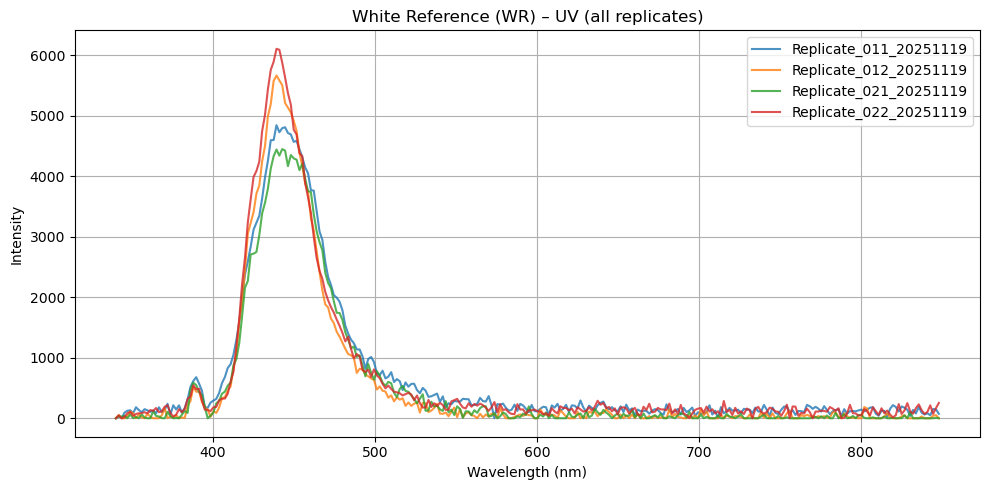

In [4]:
wr_fluo_dict = {}

for base_folder in replicate_folders:
    rep_name = os.path.basename(base_folder)
    wr_path = os.path.join(base_folder, "wr", "FLUO_WR.csv")

    if not os.path.exists(wr_path):
        print(f"Warning: WR does not exist for {rep_name}")
        continue

    wr_df = pd.read_csv(wr_path)

    wl_wr = wr_df["x"].values
    I_wr = wr_df["y"].values

    wr_fluo_dict[rep_name] = I_wr

    print(f"{rep_name} WR shape:", wr_df.shape)

    if "wavelengths" in globals():
        assert np.allclose(wavelengths, wl_wr), f"{rep_name}: WR and spectra wavelengths do not match!"

plt.figure(figsize=(10, 5))

rep_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for i, base_folder in enumerate(replicate_folders):
    rep_name = os.path.basename(base_folder)
    I_wr = wr_fluo_dict[rep_name]
    wl_wr = wavelengths

    plt.plot(wl_wr, I_wr, color=rep_colors[i], alpha=0.8, label=rep_name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("White Reference (WR) – UV (all replicates)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../plots/olive_oil/UV/UV_WR.png", dpi=300, bbox_inches="tight")
plt.show()

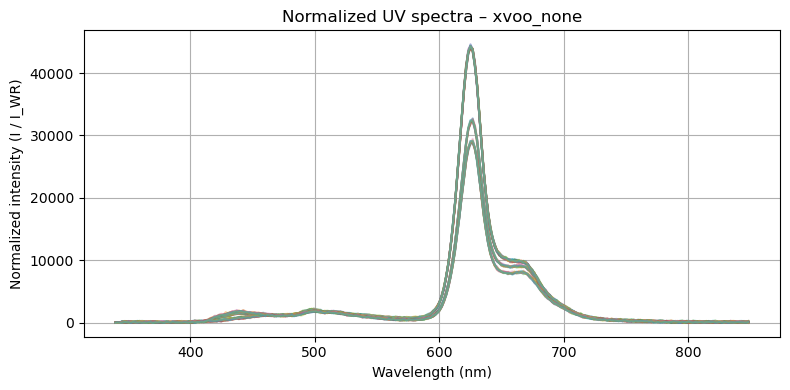

In [5]:
xvoo_none_norm = xvoo_none_raw / 1.0

plt.figure(figsize=(8, 4))

for i in range(len(xvoo_none_norm)):
    plt.plot(wavelengths, xvoo_none_norm[i], alpha=0.4)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized intensity (I / I_WR)")
plt.title("Normalized UV spectra – xvoo_none")
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
xvoo_none_norm.shape

(40, 288)

In [7]:
def _draw_rule_boundary(rule, ODcrit, SDcrit, crit, class_model=None):
    """Draws the acceptance-region boundary in (SD/SDcrit, OD/ODcrit) normalized space."""
    if rule == 'sim':
        plt.axhline(1.0, color='green', linestyle='--', label='OD threshold')
        plt.axvline(1.0, color='orange', linestyle='--', label='SD threshold')

    elif rule == 'alt':
        t = np.linspace(0, np.pi / 2, 200)
        r = crit
        plt.plot(r * np.cos(t), r * np.sin(t), color='black', linestyle='--', label=f'd = {crit:.2f} boundary')

    elif rule == 'ci':
        xb = np.linspace(0, crit, 200)
        plt.plot(xb, crit - xb, color='black', linestyle='--', label=f'c = {crit:.2f} boundary')

    elif rule == 'dd':
        OD0 = class_model.thresholds.get('OD0', np.mean(class_model.OD_train))
        SD0 = class_model.thresholds.get('SD0', np.mean(class_model.SD_train))
        s2_OD = class_model.thresholds.get('s2_OD', np.var(class_model.OD_train, ddof=1))
        s2_SD = class_model.thresholds.get('s2_SD', np.var(class_model.SD_train, ddof=1))
        LOD = (2 * (OD0 ** 2)) / (s2_OD + 1e-18)
        LSD = (2 * (SD0 ** 2)) / (s2_SD + 1e-18)
        a1 = LOD * (ODcrit / OD0)
        b1 = LSD * (SDcrit / SD0)
        xb = np.linspace(0, crit / b1, 200)
        plt.plot(xb, (crit - b1 * xb) / a1, color='black', linestyle='--', label=f'f = {crit:.2f} boundary')

    else:
        raise ValueError(f"Unknown rule: {rule}")


def _draw_rule_boundary_raw(rule, ODcrit, SDcrit, crit, class_model=None):
    """Draws the acceptance-region boundary in raw (SD, OD) space."""
    if rule == 'sim':
        plt.axhline(ODcrit, color='green', linestyle='--', label='OD threshold')
        plt.axvline(SDcrit, color='orange', linestyle='--', label='SD threshold')

    elif rule == 'alt':
        sd_b = np.linspace(0, SDcrit * crit, 200)
        od_b = ODcrit * np.sqrt(np.clip(crit ** 2 - (sd_b / SDcrit) ** 2, 0, None))
        plt.plot(sd_b, od_b, color='black', linestyle='--', label=f'd = {crit:.2f} boundary')

    elif rule == 'ci':
        sd_b = np.linspace(0, crit * SDcrit, 200)
        od_b = ODcrit * (crit - sd_b / SDcrit)
        plt.plot(sd_b, od_b, color='black', linestyle='--', label=f'c = {crit:.2f} boundary')

    elif rule == 'dd':
        OD0 = class_model.thresholds.get('OD0', np.mean(class_model.OD_train))
        SD0 = class_model.thresholds.get('SD0', np.mean(class_model.SD_train))
        s2_OD = class_model.thresholds.get('s2_OD', np.var(class_model.OD_train, ddof=1))
        s2_SD = class_model.thresholds.get('s2_SD', np.var(class_model.SD_train, ddof=1))
        LOD = (2 * (OD0 ** 2)) / (s2_OD + 1e-18)
        LSD = (2 * (SD0 ** 2)) / (s2_SD + 1e-18)
        sd_b = np.linspace(0, crit * SD0 / LSD, 200)
        od_b = OD0 * (crit - LSD * (sd_b / SD0)) / LOD
        plt.plot(sd_b, od_b, color='black', linestyle='--', label=f'f = {crit:.2f} boundary')

    else:
        raise ValueError(f"Unknown rule: {rule}")


def plot_simca_class_check(res, rule, class_model, spectrum_label="FLUO", class_label="XVOO_NONE"):
    """
    Normalized OD/SD self-check plot (SD/SDcrit vs OD/ODcrit), colored by inside/outside.
    Boundary geometry adapts to the SIMCA decision rule ('sim', 'alt', 'ci', 'dd').
    """
    OD, SD = res['OD'], res['SD']
    ODcrit, SDcrit = res['ODcrit'], res['SDcrit']
    x, y = SD / SDcrit, OD / ODcrit

    colors = np.where(res['inside'], 'blue', 'red')

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, c=colors, edgecolor='k')

    _draw_rule_boundary(rule, ODcrit, SDcrit, res['crit'], class_model)

    plt.xlabel("SD / SDcrit", fontsize=14)
    plt.ylabel("OD / ODcrit", fontsize=14)
    plt.title(f"SIMCA ({spectrum_label}) - {class_label}", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_simca_multiclass(res, y_all, classes, class_colors, rule, class_model,
                           spectrum_label="FLUO", bbox_to_anchor=None):
    """
    Normalized OD/SD plot (SD/SDcrit vs OD/ODcrit) across all classes, colored per class.
    Boundary geometry adapts to the SIMCA decision rule ('sim', 'alt', 'ci', 'dd').
    """
    OD, SD = res['OD'], res['SD']
    ODcrit, SDcrit = res['ODcrit'], res['SDcrit']
    x, y = SD / SDcrit, OD / ODcrit

    plt.figure(figsize=(8, 5))

    for cls in classes:
        idx = y_all == cls
        plt.scatter(x[idx], y[idx], color=class_colors[cls], edgecolor='k', label=cls, s=60)

    _draw_rule_boundary(rule, ODcrit, SDcrit, res['crit'], class_model)

    plt.xlabel("SD / SDcrit", fontsize=18)
    plt.ylabel("OD / ODcrit", fontsize=18)
    plt.title(f"SIMCA - {spectrum_label} model results", fontsize=20)
    plt.legend(
        loc='upper left',
        bbox_to_anchor=bbox_to_anchor,
        ncol=2,
        fontsize=12,
        frameon=True
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [8]:
X = xvoo_none_norm
y = np.array(["XVOO_NONE"] * X.shape[0])

simca = SIMCAModel(alpha=alpha, default_n_components=None)

# comp_grid = list(range(1, min(10, X.shape[1])+1))
# best_components = simca.tune_num_components(
#    X, y,
#    comp_grid=comp_grid,
#    cv=5,
#    mode='rigorous',    # 'rigorous', 'compliant'
#    rule=rule,
#    od_method=od_method,
#    sd_method=sd_method
# )
# print("Optimal number of PCA components per class:", best_components)

simca.fit(X, y, n_components=n_components)

simca.set_thresholds_all(od_method=od_method, sd_method=sd_method)

results = simca.predict(X, rule=rule)
res = results['XVOO_NONE']

n_inside = int(res['inside'].sum())
n_total = len(res['inside'])

print("SIMCA thresholds:")
print("ODcrit:", res.get('ODcrit', None))
print("SDcrit:", res.get('SDcrit', None))
print(f"Inside class: {n_inside}/{n_total} ({n_inside / n_total * 100:.1f}%)")

SIMCA thresholds:
ODcrit: 17017326.01820535
SDcrit: 7.5161136547054745
Inside class: 40/40 (100.0%)


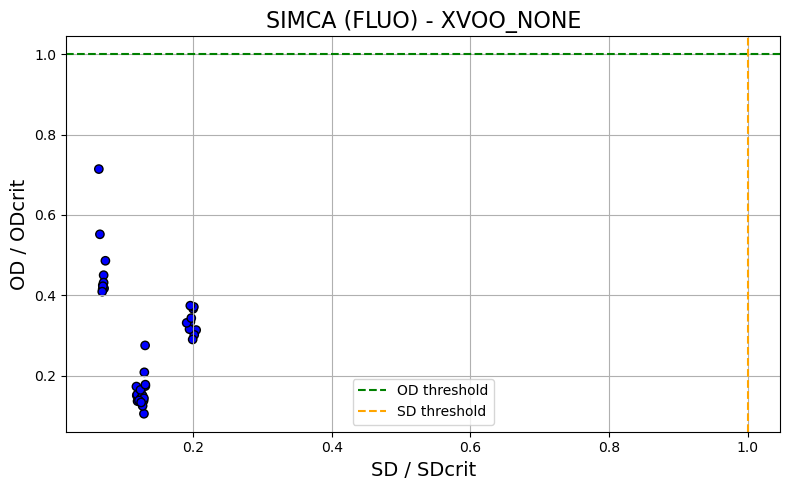

In [9]:
plot_simca_class_check(res, rule, simca.class_models['XVOO_NONE'], spectrum_label="FLUO", class_label="XVOO_NONE")

In [10]:
github_path = Path.home() / "Documents/Github"
ai_spectra = github_path / "aiSpectra" / "data" / "olive_oil"

datasets = [
    {
        "base_folder": ai_spectra / "Replicate_011/Replicate_011_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100", "xvoo_oo50",
                     "xvoo_oo100", "xvoo_sfo50", "xvoo_sfo100"]
    },
    {
        "base_folder": ai_spectra / "Replicate_011/Replicate_011_20251205",
        "mixtures": ["xvoo_oo10", "xvoo_oo20", "xvoo_oo30", "xvoo_oo40",
                     "xvoo_oo60", "xvoo_oo70", "xvoo_oo80"]
    },
    {
        "base_folder": ai_spectra / "Replicate_011/Replicate_011_20251230",
        "mixtures": ["xvoo_lso10", "xvoo_lso20", "xvoo_lso30", "xvoo_lso40",
                     "xvoo_lso60", "xvoo_lso70", "xvoo_lso80", "xvoo_lso90",
                     "xvoo_lso100", "xvoo_none", "xvoo_oo90"]
    },
    {
        "base_folder": ai_spectra / "Replicate_012/Replicate_012_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    },
    {
        "base_folder": ai_spectra / "Replicate_012/Replicate_012_20251205",
        "mixtures": ["xvoo_oo10", "xvoo_oo20", "xvoo_oo30", "xvoo_oo40",
                     "xvoo_oo60", "xvoo_oo70", "xvoo_oo80"]
    },
    {
        "base_folder": ai_spectra / "Replicate_021/Replicate_021_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    },
    {
        "base_folder": ai_spectra / "Replicate_022/Replicate_022_20251119",
        "mixtures": ["xvoo_lso50", "xvoo_lso100",
                     "xvoo_oo50", "xvoo_oo100",
                     "xvoo_sfo50", "xvoo_sfo100"]
    }
]

In [11]:
X_list = []
y_list = []

for ds in datasets:
    base_folder = ds["base_folder"]
    mixtures = ds["mixtures"]

    wr_file = os.path.join(base_folder, "wr", "FLUO_WR.csv")
    wr = pd.read_csv(wr_file).iloc[:, 1].values

    print(f"\nLoading data from: {base_folder}")
    print(f"WR shape: {wr.shape}")

    for mix in mixtures:
        uv_folder = os.path.join(base_folder, mix, "FLUO")

        if not os.path.exists(uv_folder):
            print(f"Warning: folder does not exist {uv_folder}, skipping...")
            continue

        files = sorted([f for f in os.listdir(uv_folder) if f.endswith(".csv")])

        for f in files:
            df = pd.read_csv(os.path.join(uv_folder, f))
            spectrum = df.iloc[:, 1].values
            spectrum_norm = spectrum / 1.0

            X_list.append(spectrum_norm)
            y_list.append(mix)
    
X_all_norm = np.array(X_list)
y_all = np.array(y_list)

print("Shape X_all_norm:", X_all_norm.shape)
print("Shape y_all:", y_all.shape)

print("Unique classes:", np.unique(y_all))


Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/olive_oil/Replicate_011/Replicate_011_20251119
WR shape: (288,)

Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/olive_oil/Replicate_011/Replicate_011_20251205
WR shape: (288,)

Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/olive_oil/Replicate_011/Replicate_011_20251230
WR shape: (288,)

Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/olive_oil/Replicate_012/Replicate_012_20251119
WR shape: (288,)

Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/olive_oil/Replicate_012/Replicate_012_20251205
WR shape: (288,)

Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/olive_oil/Replicate_021/Replicate_021_20251119
WR shape: (288,)

Loading data from: /home/vizlore/Documents/Github/aiSpectra/data/olive_oil/Replicate_022/Replicate_022_20251119
WR shape: (288,)
Shape X_all_norm: (1010, 288)
Shape y_all: (1010,)
Unique classes: ['xvoo_lso10' 'xvoo_lso

In [12]:
results_mix = simca.predict(X_all_norm, rule=rule)
res_mix = results_mix['XVOO_NONE']

ODcrit = simca.class_models['XVOO_NONE'].thresholds['ODcrit']
SDcrit = simca.class_models['XVOO_NONE'].thresholds['SDcrit']

print("OD threshold:", ODcrit)
print("SD threshold:", SDcrit)

inside = res_mix['inside']
# for i, accepted in enumerate(inside):
    # print(f"Sample {i} ({y_all[i]}): {'Accepted' if accepted else 'Rejected'}")

OD threshold: 17017326.01820535
SD threshold: 7.5161136547054745


In [13]:
%matplotlib qt

In [14]:
SD = res_mix['SD']
OD = res_mix['OD']

classes = np.unique(y_all)
num_classes = len(classes)

cmap = plt.get_cmap("tab20")
class_colors = {cls: cmap(i / num_classes) for i, cls in enumerate(classes)}

plt.figure(figsize=(8,5))

for cls in classes:
    idx = y_all == cls
    plt.scatter(SD[idx], OD[idx], color=class_colors[cls], edgecolor='k', label=cls, s=60)

_draw_rule_boundary_raw(rule, ODcrit, SDcrit, res_mix['crit'], simca.class_models['XVOO_NONE'])

plt.xlabel("Score Distance (SD)", fontsize=18)
plt.ylabel("Orthogonal Distance (OD)", fontsize=18)
plt.title("SIMCA – All FLUO data by class", fontsize=22)
plt.legend(loc='upper left', ncol=2, fontsize=12, frameon=True)
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
plot_simca_multiclass(
    res_mix, y_all, classes, class_colors, rule, simca.class_models['XVOO_NONE'],
    spectrum_label="FLUO"
)

In [16]:
y_true = np.array([label == "xvoo_none" for label in y_all])

y_pred = res_mix['inside']

TP = np.sum((y_true == True) & (y_pred == True))
FN = np.sum((y_true == True) & (y_pred == False))
FP = np.sum((y_true == False) & (y_pred == True))
TN = np.sum((y_true == False) & (y_pred == False))

conf_matrix = pd.DataFrame(
    [[TP, FN],
     [FP, TN]],
    index=["True XVOO", "True MIX"],
    columns=["Predicted IN", "Predicted OUT"]
)

conf_matrix

,Predicted IN,Predicted OUT
True XVOO,50,0
True MIX,0,960


In [17]:
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Sensitivity (Recall for XVOO): {sensitivity*100:.2f}%")
print(f"Specificity (Rejection of MIX): {specificity*100:.2f}%")
print(f"Accuracy: {accuracy*100:.2f}%")

Sensitivity (Recall for XVOO): 100.00%
Specificity (Rejection of MIX): 100.00%
Accuracy: 100.00%


In [18]:
results_table = pd.DataFrame({
    "Sample index": np.arange(len(y_all)),
    "True label": y_all,
    "SIMCA accepted": y_pred,
    "Decision": np.where(y_pred, "Accepted", "Rejected"),
    "SD": res_mix['SD'],
    "OD": res_mix['OD']
})

results_table.head(10)

,Sample index,True label,SIMCA accepted,Decision,SD,OD
0,0,xvoo_lso50,False,Rejected,0.019356,3.387205e+08
1,1,xvoo_lso50,False,Rejected,0.017693,3.367685e+08
2,2,xvoo_lso50,False,Rejected,0.017163,3.288162e+08
3,3,xvoo_lso50,False,Rejected,0.018078,3.318325e+08
4,4,xvoo_lso50,False,Rejected,0.016093,3.393275e+08
5,5,xvoo_lso50,False,Rejected,0.017276,3.325851e+08
6,6,xvoo_lso50,False,Rejected,0.017026,3.379357e+08
7,7,xvoo_lso50,False,Rejected,0.021844,3.348516e+08
8,8,xvoo_lso50,False,Rejected,0.018501,3.379721e+08
9,9,xvoo_lso50,False,Rejected,0.015870,3.496272e+08
